In [1]:
from tqdm import tqdm
import polars as pl
import numpy as np
import catboost as cb
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression

music = pl.read_csv('data/charts.csv')
data = pl.read_csv('data/prices.csv')
music = music.filter(pl.col('chart') == 'top200')
music = music.drop(['artist', 'chart', 'rank', 'url'])

regions = music['region'].unique()

music = music.with_columns(pl.col('streams').sum().over('region', 'date').alias('S'))
music = music.unique(['region', 'date']).sort('date')
print(music)

dates = data['Date']
Y = np.concat([np.diff(data['SPY_Close'].to_numpy()), [0]])
# Y = np.concat([np.diff(data['XLP_Close'].to_numpy()), [0]])
print(Y.shape, len(dates))

X = []

for d in tqdm(dates):
    s = []
    for r in regions:
        v = music.filter((pl.col('region') == r) & (pl.col('date') == d))['S'].to_list()
        if len(v) > 0:
            s.append(v[0])
        else:
            s.append(0)
    X.append(s)
X = np.array(X)
print(X.shape)
print(X, Y)

shape: (109_991, 6)
┌─────────────────────────┬────────────┬──────────────────────┬───────────────┬─────────┬──────────┐
│ title                   ┆ date       ┆ region               ┆ trend         ┆ streams ┆ S        │
│ ---                     ┆ ---        ┆ ---                  ┆ ---           ┆ ---     ┆ ---      │
│ str                     ┆ str        ┆ str                  ┆ str           ┆ i64     ┆ i64      │
╞═════════════════════════╪════════════╪══════════════════════╪═══════════════╪═════════╪══════════╡
│ Safari                  ┆ 2017-01-01 ┆ Nicaragua            ┆ SAME_POSITION ┆ 2786    ┆ 33228    │
│ Starboy                 ┆ 2017-01-01 ┆ Portugal             ┆ SAME_POSITION ┆ 15397   ┆ 598247   │
│ Rockabye (feat. Sean    ┆ 2017-01-01 ┆ Hungary              ┆ MOVE_UP       ┆ 6263    ┆ 203462   │
│ Paul & An…              ┆            ┆                      ┆               ┆         ┆          │
│ Starboy                 ┆ 2017-01-01 ┆ Canada               ┆ SAME_PO

100%|██████████████████████████████████████████████████████████████████████████████████████| 1152/1152 [00:24<00:00, 46.46it/s]

(1152, 69)
[[ 1635053  4396092     7863 ...        0  2360613        0]
 [ 1632689  4450076     6797 ...        0  2403061        0]
 [ 1631344  4530468     7954 ...        0  2425707        0]
 ...
 [ 5454692 12846301        0 ...   938128 15483557   668305]
 [ 5050425 13068181        0 ...   926651 15241706   699674]
 [ 5329684 13819085        0 ...   832118 14995016   679582]] [ 1.15698242 -0.15544128  0.6993103  ...  1.70532227 -2.00515747
  0.        ]


In [56]:
Y = np.concat([np.diff(data['SPY_Close'].to_numpy()), [0]])
# Y = np.roll(Y, 1)
# Y = data['SPY_Close'].to_numpy()
XX = X / (X.sum(1, keepdims=True) + 1e-8)
# print(XX)
X_train, X_val, Y_train, Y_val = train_test_split(XX, Y, shuffle=False, test_size=0.8)

# model = cb.CatBoostRegressor(depth=3, verbose=0)
model = Ridge(0.0000001)
model.fit(X_train, Y_train)
print(model.score(X_train, Y_train))
print(model.score(X_val, Y_val))

0.20351182824086123
-3.677405129964608


In [3]:
X, Y

(array([[ 1635053,  4396092,     7863, ...,        0,  2360613,        0],
        [ 1632689,  4450076,     6797, ...,        0,  2403061,        0],
        [ 1631344,  4530468,     7954, ...,        0,  2425707,        0],
        ...,
        [ 5454692, 12846301,        0, ...,   938128, 15483557,   668305],
        [ 5050425, 13068181,        0, ...,   926651, 15241706,   699674],
        [ 5329684, 13819085,        0, ...,   832118, 14995016,   679582]],
       shape=(1152, 69)),
 array([ 1.15698242, -0.15544128,  0.6993103 , ...,  1.70532227,
        -2.00515747,  0.        ], shape=(1152,)))

In [4]:
import matplotlib.pyplot as plt

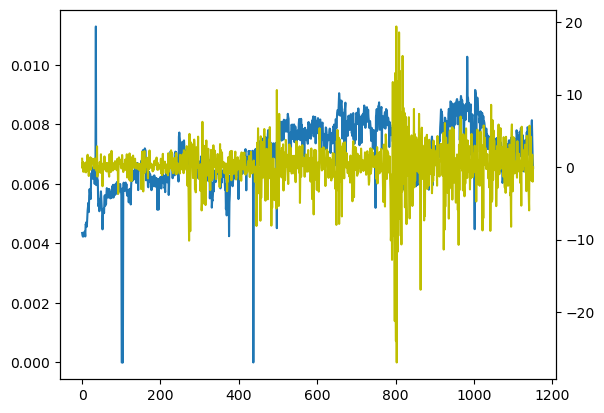

In [57]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(XX[:, 0])
ax2.plot(Y, c='y')